In [1]:
# Cell 1 — Imports
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
# Cell 2 — Load Data
csv_path = Path("../Data/events.csv")
raw_df = pd.read_csv(csv_path)

df = raw_df[["visitorid", "timestamp", "event"]].copy()
df = df[df["event"].isin(["view", "addtocart", "transaction"])].copy()
df["timestamp"] = pd.to_datetime(df["timestamp"], unit="ms")
df = df.sort_values(["visitorid", "timestamp"]).reset_index(drop=True)

print("Shape:", df.shape)
print("\nEvent value counts:")
print(df["event"].value_counts())

Shape: (2756101, 3)

Event value counts:
event
view           2664312
addtocart        69332
transaction      22457
Name: count, dtype: int64


In [3]:
# Cell 3 — State Mapping
state_map = {
    "view": "Browse",
    "addtocart": "Add_to_Cart",
    "transaction": "Purchase",
}
df["state"] = df["event"].map(state_map)
print(df[["visitorid", "timestamp", "event", "state"]].head())

   visitorid               timestamp event   state
0          0 2015-09-11 20:49:49.439  view  Browse
1          0 2015-09-11 20:52:39.591  view  Browse
2          0 2015-09-11 20:55:17.175  view  Browse
3          1 2015-08-13 17:46:06.444  view  Browse
4          2 2015-08-07 17:51:44.567  view  Browse


In [4]:
# Cell 4 — Build Sequences WITH Exit state
sequences = (
    df.groupby("visitorid")["state"]
    .apply(list)
    .apply(lambda seq: seq + ["Exit"])
)

print("Total sequences:", len(sequences))
print("\n5 sample sequences:")
for i, seq in enumerate(sequences.head(5), start=1):
    preview = seq[:15]
    suffix = " ..." if len(seq) > 15 else ""
    print(f"{i}. {preview}{suffix}")

Total sequences: 1407580

5 sample sequences:
1. ['Browse', 'Browse', 'Browse', 'Exit']
2. ['Browse', 'Exit']
3. ['Browse', 'Browse', 'Browse', 'Browse', 'Browse', 'Browse', 'Browse', 'Browse', 'Exit']
4. ['Browse', 'Exit']
5. ['Browse', 'Exit']


In [5]:
# Cell 5 — Build Transition Matrix
pairs = []
for seq in sequences:
    pairs.extend(list(zip(seq[:-1], seq[1:])))

transitions_df = pd.DataFrame(pairs, columns=["from_state", "to_state"])
transition_counts = pd.crosstab(transitions_df["from_state"], transitions_df["to_state"])

# Exit is absorbing: drop from row index (no outgoing transitions to model)
if "Exit" in transition_counts.index:
    transition_counts = transition_counts.drop(index="Exit")

transition_probs = transition_counts.div(transition_counts.sum(axis=1), axis=0)

print("Transition count table:")
print(transition_counts)
print("\nTransition probability matrix:")
print(transition_probs.round(4))

Transition count table:
to_state     Add_to_Cart   Browse     Exit  Purchase
from_state                                          
Add_to_Cart        11552    31256    14032     12492
Browse             51975  1220040  1387309      4988
Purchase             356    11003     6239      4859

Transition probability matrix:
to_state     Add_to_Cart  Browse    Exit  Purchase
from_state                                        
Add_to_Cart       0.1666  0.4508  0.2024    0.1802
Browse            0.0195  0.4579  0.5207    0.0019
Purchase          0.0159  0.4900  0.2778    0.2164


In [6]:
# Cell 6 — Validate Matrix
row_sums = transition_probs.sum(axis=1)
print("Row sums:")
print(row_sums)

assert np.allclose(row_sums.values, 1.0, atol=1e-6), "Row sums must equal 1.0"
print("\n✅ Matrix is valid")

Row sums:
from_state
Add_to_Cart    1.0
Browse         1.0
Purchase       1.0
dtype: float64

✅ Matrix is valid


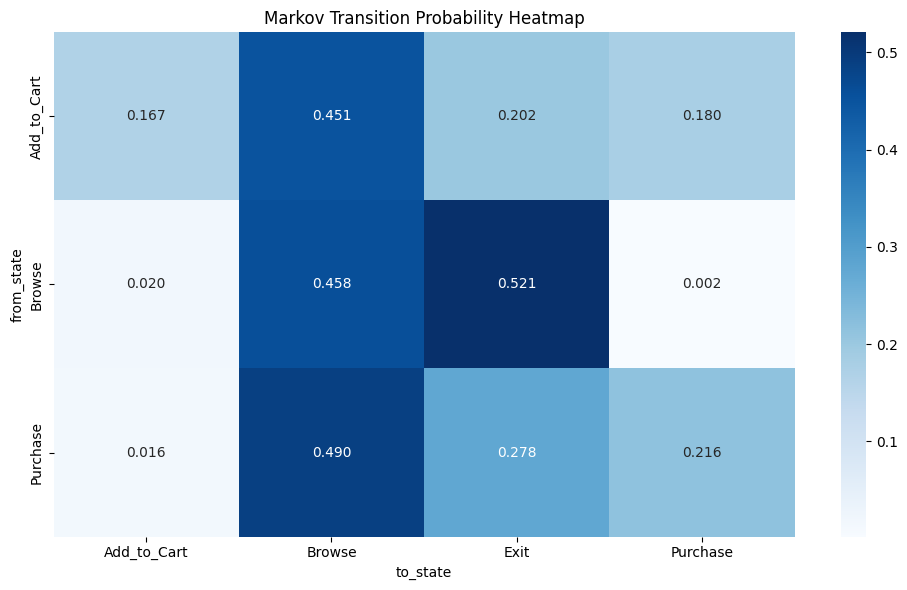

In [7]:
# Cell 7 — Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(
    transition_probs,
    annot=True,
    fmt=".3f",
    cmap="Blues",
)
plt.title("Markov Transition Probability Heatmap")
plt.tight_layout()

heatmap_path = Path("../app/heatmap.png")
heatmap_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(heatmap_path, dpi=150, bbox_inches="tight")
plt.show()

In [8]:
# Cell 8 — Prediction Function


def predict_next_state(current_state: str, prob_matrix: pd.DataFrame) -> pd.Series:
    if current_state not in prob_matrix.index:
        raise ValueError(
            f"Unknown state '{current_state}'. Valid states: {list(prob_matrix.index)}"
        )
    return prob_matrix.loc[current_state].sort_values(ascending=False)


print("Prediction from 'Browse':")
print(predict_next_state("Browse", transition_probs))
print("\nPrediction from 'Add_to_Cart':")
print(predict_next_state("Add_to_Cart", transition_probs))

Prediction from 'Browse':
to_state
Exit           0.520701
Browse         0.457919
Add_to_Cart    0.019508
Purchase       0.001872
Name: Browse, dtype: float64

Prediction from 'Add_to_Cart':
to_state
Browse         0.450816
Exit           0.202389
Purchase       0.180177
Add_to_Cart    0.166619
Name: Add_to_Cart, dtype: float64


In [9]:
# Cell 9 — Business Insights (FUNNEL DROP-OFF analysis)
total_visitors = df["visitorid"].nunique()
purchasers = df.loc[df["state"] == "Purchase", "visitorid"].nunique()
cart_visitors = df.loc[df["state"] == "Add_to_Cart", "visitorid"].nunique()

overall_conversion = (purchasers / total_visitors * 100) if total_visitors else 0.0
cart_to_purchase = (purchasers / cart_visitors * 100) if cart_visitors else 0.0

print("Total unique visitors:", total_visitors)
print("Total purchasers (unique visitors with Purchase):", purchasers)
print(f"Overall conversion rate: {overall_conversion:.4f}%")
print(f"Cart-to-purchase rate: {cart_to_purchase:.4f}%")
print()
print("--- FUNNEL DROP-OFF analysis (from Markov matrix) ---")
b_exit = transition_probs.loc["Browse", "Exit"] * 100
b_cart = transition_probs.loc["Browse", "Add_to_Cart"] * 100
ac_exit = transition_probs.loc["Add_to_Cart", "Exit"] * 100
ac_purchase = transition_probs.loc["Add_to_Cart", "Purchase"] * 100
print(f"Browse → Exit % (session drop-off): {b_exit:.4f}%")
print(f"Browse → Add_to_Cart % (engagement): {b_cart:.4f}%")
print(f"Add_to_Cart → Exit % (cart abandonment): {ac_exit:.4f}%")
print(f"Add_to_Cart → Purchase % (conversion): {ac_purchase:.4f}%")

Total unique visitors: 1407580
Total purchasers (unique visitors with Purchase): 11719
Overall conversion rate: 0.8326%
Cart-to-purchase rate: 31.0668%

--- FUNNEL DROP-OFF analysis (from Markov matrix) ---
Browse → Exit % (session drop-off): 52.0701%
Browse → Add_to_Cart % (engagement): 1.9508%
Add_to_Cart → Exit % (cart abandonment): 20.2389%
Add_to_Cart → Purchase % (conversion): 18.0177%


In [10]:
# Cell 10 — Save Matrix
app_dir = Path("../app")
app_dir.mkdir(parents=True, exist_ok=True)

pkl_path = app_dir / "transition_probs.pkl"
csv_path_out = app_dir / "transition_probs.csv"

with open(pkl_path, "wb") as f:
    pickle.dump(transition_probs, f)

transition_probs.to_csv(csv_path_out)

print(f"Saved: {pkl_path.resolve()}")
print(f"Saved: {csv_path_out.resolve()}")

Saved: /Users/punitjadhav/Documents/pgm_project/customer_prediction/app/transition_probs.pkl
Saved: /Users/punitjadhav/Documents/pgm_project/customer_prediction/app/transition_probs.csv
